In [1]:
import duckdb
import pandas as pd
import numpy as np

In [2]:
DB_PATH = "../mls_dp_transfers.db"

STANDARD_MINS = 96

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)

# Player Data Retrieval

### Player per-season stats

In [4]:
# Initial player collection query

player_query = """
SELECT

    player_id,
    player_name,

    CAST(season_name AS INTEGER) AS season,

    ARG_MAX(general_position, minutes_played)
        AS primary_position,

    ARG_MAX(team_name, minutes_played)
        AS primary_team,

    SUM(minutes_played) AS minutes,

    COUNT(DISTINCT game_id) AS games_played,

    -- shooting
    SUM(shots) AS shots,
    SUM(shots_on_target) AS shots_on_target,

    -- scoring
    SUM(goals) AS goals,
    SUM(xgoals) AS xg,

    -- creation
    SUM(primary_assists) AS assists,
    SUM(xassists) AS xa,
    SUM(key_passes) AS key_passes,

    -- combined production
    SUM(goals_plus_primary_assists) AS g_plus_a,
    SUM(xgoals_plus_xassists) AS xg_plus_xa,

    -- possession value
    SUM(points_added) AS points_added,
    SUM(xpoints_added) AS xpoints_added,

    -- efficiency surplus
    SUM(goals_minus_xgoals) AS goals_minus_xg,
    SUM(primary_assists_minus_xassists)
        AS assists_minus_xa

FROM asa_dp_att_xg

GROUP BY
    player_id,
    player_name,
    season
"""

players = con.execute(player_query).df()

### All players goals added stats

In [5]:
# Retrieve goals added totals

ga_query = """

SELECT

    player_id,

    COUNT(*) AS ga_rows,

    SUM(goals_added_raw)
        AS goals_added_raw,

    SUM(goals_added_above_avg)
        AS goals_added_above_avg,

    SUM(count_actions)
        AS total_actions

FROM asa_player_ga

GROUP BY
    player_id

"""

ga = con.execute(ga_query).df()

In [6]:
# Merge goals added into player dataset
df = players.merge(
    ga,
    on="player_id",
    how="left"
)

### Player personal info

In [7]:
# Add player personal info

player_data_query = """
SELECT DISTINCT
    player_id,
    birth_date,
    nationality
FROM asa_players
"""

player_data = con.execute(player_data_query).df()

In [8]:
# Add it to the df
df = df.merge(
    player_data,
    on="player_id",
    how="left"
)

### Retrieve DP-specific data

In [9]:
# Add player team details info to df

dp_data_query = """

SELECT DISTINCT

    player_id,

    years_as_dp,
    first_year_as_dp,
    transfer_from

FROM dp_attackers

"""

dp_meta = con.execute(dp_data_query).df()

In [10]:
# Add it to the df
df = df.merge(
    dp_meta,
    on="player_id",
    how="left"
)

In [11]:
# Calculate the age of the player to include in the PCA

df["birth_date"] = pd.to_datetime(
    df["birth_date"],
    errors="coerce"
)

df["age"] = (
    df["season"]
    - df["birth_date"].dt.year
)

In [12]:
# Create the per-96 normalized columns

norm_cols = [

    "shots",
    "shots_on_target",

    "goals",
    "xg",

    "assists",
    "xa",

    "key_passes",

    "g_plus_a",
    "xg_plus_xa",

    "points_added",
    "xpoints_added",

    "goals_minus_xg",
    "assists_minus_xa",

    "goals_added_raw",
    "goals_added_above_avg"
]

for col in norm_cols:

    df[f"{col}_per96"] = (
        df[col]
        / df["minutes"]
        * STANDARD_MINS
    )

In [13]:
# Add derived metics

# Shot quality
df["xg_per_shot"] = np.where(
    df["shots"] > 0,
    df["xg"] / df["shots"],
    np.nan
)

# Shot accuracy
df["shot_accuracy"] = np.where(
    df["shots"] > 0,
    df["shots_on_target"] / df["shots"],
    np.nan
)

# Goal conversion
df["goal_conversion"] = np.where(
    df["shots"] > 0,
    df["goals"] / df["shots"],
    np.nan
)

# SoT conversion
df["sot_conversion"] = np.where(
    df["shots_on_target"] > 0,
    df["goals"] / df["shots_on_target"],
    np.nan
)

# Creative efficiency
df["assist_efficiency"] = np.where(
    df["xa"] > 0,
    df["assists"] / df["xa"],
    np.nan
)

In [14]:
# Aggregate and divide season totals for smoothing results

team_query = """

SELECT

    t.team_id,

    g.season_name AS season,

    AVG(t.xgoals_for)
        AS team_xgf,

    AVG(t.xgoals_against)
        AS team_xga,

    AVG(t.xpoints)
        AS team_xpoints,

    AVG(t.goal_difference)
        AS team_goal_diff,

    AVG(t.xgoal_difference)
        AS team_xgoal_diff

FROM asa_team_xg t

JOIN asa_games g
    ON t.game_id = g.game_id

GROUP BY
    t.team_id,
    season

"""

team_context = con.execute(team_query).df()

In [15]:
# Assign the player's primary team in the df

team_id_query = """

SELECT

    player_id,

    CAST(season_name AS INTEGER) AS season,

    ARG_MAX(team_id, minutes_played)
        AS primary_team_id

FROM asa_dp_att_xg

GROUP BY
    player_id,
    season

"""

team_ids = con.execute(team_id_query).df()

In [16]:
# Add the team info to the df

df = df.merge(
    team_ids,
    on=["player_id", "season"],
    how="left"
)

# Add team metrics

df = df.merge(
    team_context,
    left_on=["primary_team_id", "season"],
    right_on=["team_id", "season"],
    how="left"
)

In [17]:
# Remove seasons with small minutes samples

df = df[df["minutes"] >= 450].copy()

In [18]:
# Sort all values by season and player

df = df.sort_values(
    ["season", "player_name"]
).reset_index(drop=True)

# Feature Selection and Scaling

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [20]:
feature_cols = [

    "shots_per96",

    "xg_per96",
    "xg_per_shot",

    "goals_minus_xg_per96",

    "xa_per96",
    "key_passes_per96",

    "goals_added_above_avg_per96",
    "points_added_per96",

    "age"
]

X = df[feature_cols].copy()

In [21]:
# Trim features to avoid outlier interference

for col in feature_cols:

    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)

    X[col] = X[col].clip(lower, upper)

In [22]:
# Standardization of all features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=df.index
)

In [23]:
print("\nResults of Scaling:")
print(X_scaled.describe().round(3))


Results of Scaling:
       shots_per96  xg_per96  xg_per_shot  goals_minus_xg_per96  xa_per96  \
count      555.000   555.000      555.000               555.000   555.000   
mean         0.000     0.000       -0.000                -0.000    -0.000   
std          1.001     1.001        1.001                 1.001     1.001   
min         -2.072    -1.732       -1.927                -2.662    -1.654   
25%         -0.699    -0.757       -0.774                -0.590    -0.728   
50%         -0.003    -0.096       -0.056                 0.042    -0.194   
75%          0.613     0.626        0.660                 0.606     0.667   
max          3.037     2.935        2.860                 3.156     2.416   

       key_passes_per96  goals_added_above_avg_per96  points_added_per96  \
count           555.000                      555.000             555.000   
mean             -0.000                       -0.000               0.000   
std               1.001                        1.001     

# Principal Component Analysis

In [24]:
# Run PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [25]:
explained_variance = pd.DataFrame({

    "PC":
        [f"PC{i+1}" for i in range(len(feature_cols))],

    "Explained_Variance":
        pca.explained_variance_ratio_,

    "Cumulative_Variance":
        np.cumsum(pca.explained_variance_ratio_)
})

print("\nExplained Variance:")
print(explained_variance.round(3))


Explained Variance:
    PC  Explained_Variance  Cumulative_Variance
0  PC1               0.319                0.319
1  PC2               0.236                0.555
2  PC3               0.130                0.685
3  PC4               0.118                0.803
4  PC5               0.093                0.896
5  PC6               0.068                0.963
6  PC7               0.018                0.981
7  PC8               0.016                0.997
8  PC9               0.003                1.000


In [26]:
# PCA Values

loadings = pd.DataFrame(

    pca.components_.T,

    columns=[
        f"PC{i+1}"
        for i in range(len(feature_cols))
    ],

    index=feature_cols
)

print("\nPCA values")
print(loadings.round(3))


PCA values
                               PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
shots_per96                  0.438  0.139 -0.199 -0.295 -0.357 -0.495 -0.171   
xg_per96                     0.558 -0.055 -0.199 -0.093  0.132 -0.091 -0.204   
xg_per_shot                  0.413 -0.195 -0.093  0.110  0.594  0.402 -0.160   
goals_minus_xg_per96         0.174  0.232  0.759  0.153 -0.229  0.188 -0.435   
xa_per96                    -0.021  0.617 -0.059 -0.172  0.312 -0.035 -0.310   
key_passes_per96            -0.097  0.616 -0.008 -0.152  0.279  0.016  0.365   
goals_added_above_avg_per96  0.140  0.306 -0.459  0.251 -0.508  0.595  0.020   
points_added_per96           0.515  0.068  0.332  0.052 -0.043  0.002  0.695   
age                          0.033  0.163 -0.112  0.866  0.119 -0.440 -0.028   

                               PC8    PC9  
shots_per96                 -0.152 -0.487  
xg_per96                    -0.152  0.739  
xg_per_shot                 -0.121 -0.464  
goals_minus

In [27]:
# Add Core PCAs to DF

for i in range(4):

    df[f"PC{i+1}"] = X_pca[:, i]

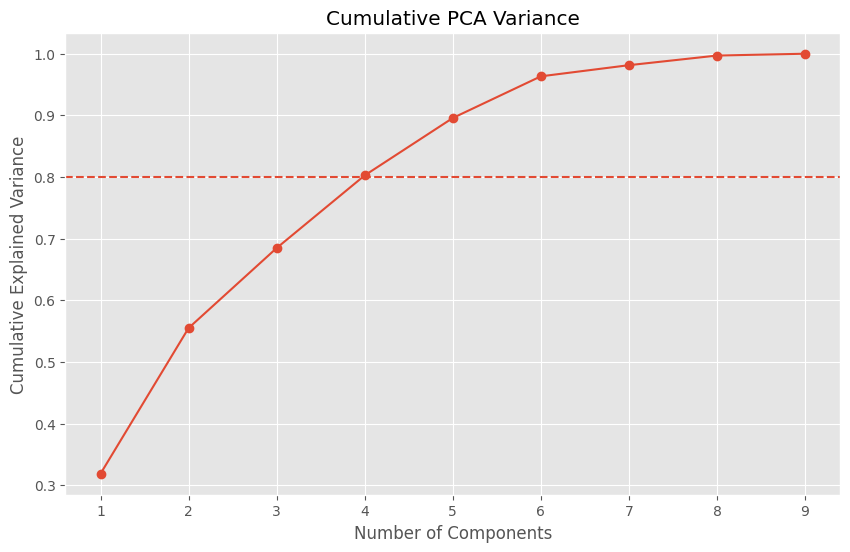

In [28]:
# Cumulative Variance Plot

plt.figure(figsize=(10, 6))

plt.plot(

    range(1, len(feature_cols) + 1),

    np.cumsum(
        pca.explained_variance_ratio_
    ),

    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative PCA Variance")

plt.axhline(
    0.80,
    linestyle="--"
)

plt.xticks(
    range(1, len(feature_cols) + 1)
)

plt.grid(True)

plt.show()

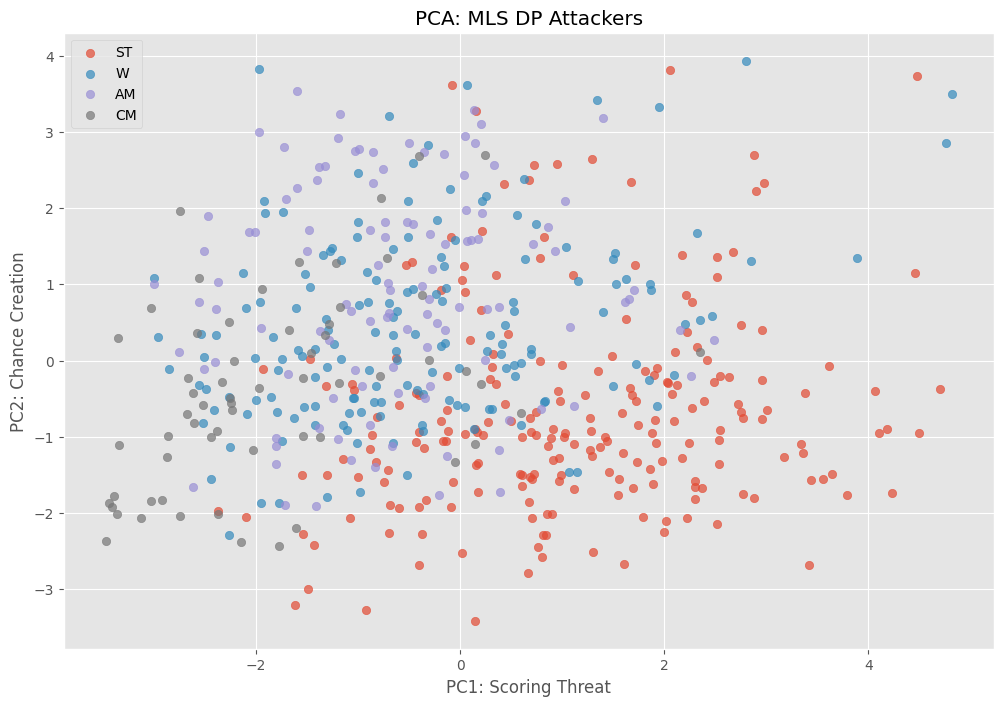

In [29]:
# PCA Plot By Position

plt.figure(figsize=(12, 8))

positions = df["primary_position"].unique()

for pos in positions:

    subset = df[
        df["primary_position"] == pos
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=pos,
        alpha=0.7
    )

plt.xlabel("PC1: Scoring Threat")
plt.ylabel("PC2: Chance Creation")

plt.title("PCA: MLS DP Attackers")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
pca_output_cols = [

    "player_name",
    "season",
    "primary_position",

    "PC1",
    "PC2",
    "PC3",
    "PC4"
]

pca_output = df[pca_output_cols].copy()

print(pca_output.head())

               player_name  season primary_position       PC1       PC2  \
0  Bradley Wright-Phillips    2015               ST  2.544046 -0.905068   
1             Carlos Rivas    2015                W -1.048051 -0.497479   
2              David Accam    2015                W  1.399171  0.640157   
3            Didier Drogba    2015               ST  4.457462  1.148718   
4         Fabian Espindola    2015               ST  0.214513  1.696991   

        PC3       PC4  
0 -1.924606  0.288656  
1 -2.228640 -2.703696  
2  0.294495 -0.650361  
3  1.931689  2.001798  
4 -0.482383 -0.314962  


# Clustering

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

In [32]:
# Find the clusters from the PCs

cluster_cols = [
    "PC1",
    "PC2",
    "PC3"
]

X_cluster = df[cluster_cols].copy()

In [33]:
# Find the best cluster amount

k_results = []

k_range = range(3, 9)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=25
    )

    labels = model.fit_predict(X_cluster)

    k_results.append({

        "k": k,
        "wcss": model.inertia_
    })

k_results = pd.DataFrame(k_results)

print("\nK-Means WCSS")
print(k_results)


K-Means WCSS
   k         wcss
0  3  1734.686352
1  4  1449.187336
2  5  1271.439617
3  6  1138.271571
4  7  1039.708368
5  8   954.136418


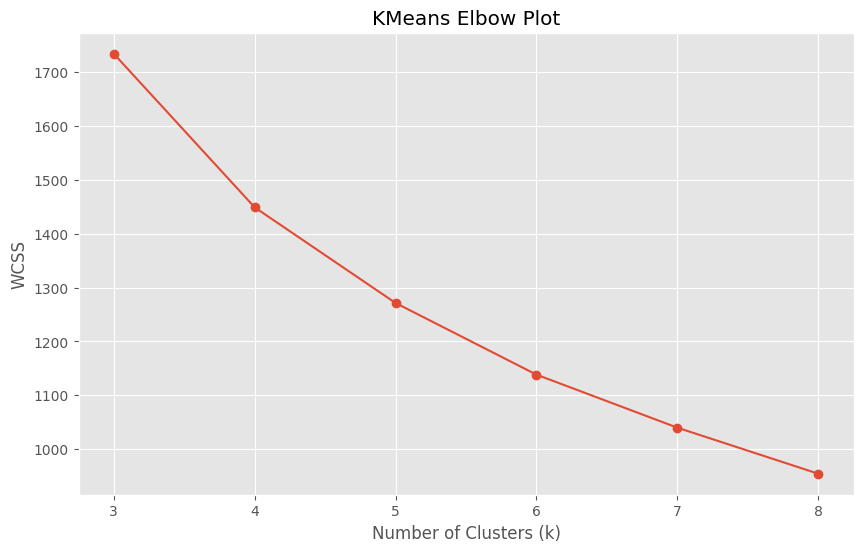

In [34]:
# Elbow Plot

plt.figure(figsize=(10, 6))

plt.plot(
    k_results["k"],
    k_results["wcss"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.title("KMeans Elbow Plot")

plt.grid(True)

plt.show()

In [35]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=50
)

df["cluster"] = kmeans.fit_predict(X_cluster)

In [36]:
# Player Count Per Cluster

print("\nPlayer Count Per Cluster")
print(
    df["cluster"]
    .value_counts()
    .sort_index()
)


Player Count Per Cluster
cluster
0    147
1     50
2    102
3    118
4    138
Name: count, dtype: int64


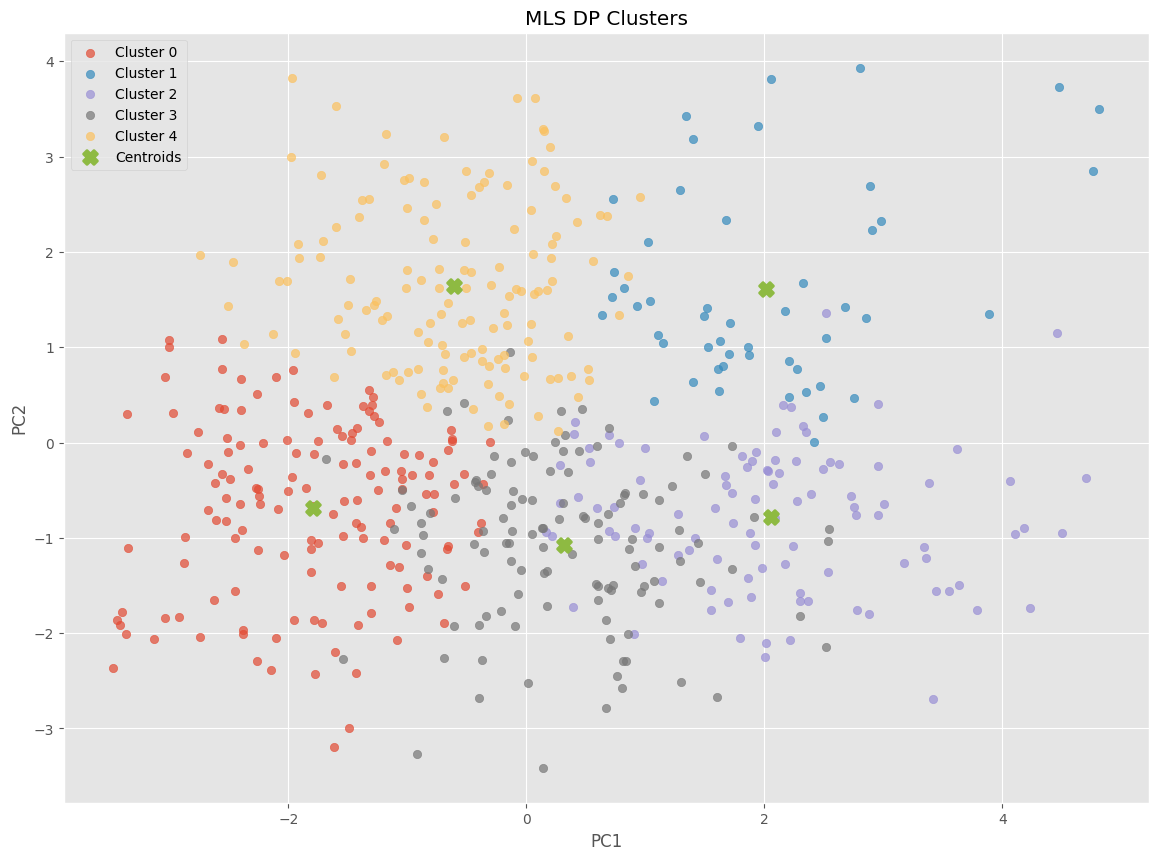

In [37]:
# PCA Cluster Split plot

plt.figure(figsize=(14, 10))

for cluster_id in sorted(df["cluster"].unique()):

    subset = df[
        df["cluster"] == cluster_id
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=f"Cluster {cluster_id}"
    )

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=100,
    linewidths=2,
    label="Centroids"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("MLS DP Clusters")

plt.legend()

plt.grid(True)

plt.show()

# Archetypes

In [38]:
# Define and develop archetypes

interpret_cols = [

    "shots_per96",
    "xg_per96",
    "xg_per_shot",

    "goals_minus_xg_per96",

    "xa_per96",
    "key_passes_per96",

    "goals_added_above_avg_per96",
    "points_added_per96",

    "age"
]

In [39]:
# All data per cluster

cluster_profiles = (

    df.groupby("cluster")[interpret_cols]
      .mean()
      .round(3)
)

print("\nCluster Values:")
print(cluster_profiles)


Cluster Values:
         shots_per96  xg_per96  xg_per_shot  goals_minus_xg_per96  xa_per96  \
cluster                                                                       
0              1.681     0.152        0.090                -0.019     0.127   
1              4.027     0.520        0.134                 0.052     0.248   
2              3.103     0.497        0.164                 0.118     0.111   
3              2.798     0.388        0.142                -0.116     0.112   
4              2.541     0.250        0.101                 0.046     0.257   

         key_passes_per96  goals_added_above_avg_per96  points_added_per96  \
cluster                                                                      
0                   1.274                        0.003               0.060   
1                   2.021                        0.695               0.264   
2                   0.997                        0.079               0.310   
3                   1.042              

In [40]:
# Clusters by position

position_dist = pd.crosstab(
    df["cluster"],
    df["primary_position"]
)

print("\nPosition Distribution:")
print(position_dist)


Position Distribution:
primary_position  AM  CM  ST   W
cluster                         
0                 25  45  19  58
1                  9   0  19  22
2                  3   2  87  10
3                 12   4  77  25
4                 62  10  17  49


In [41]:
# Top players per cluster

print("\nTop Players Per Cluster:\n")

for cluster_id in sorted(df["cluster"].unique()):

    print(f"Cluster {cluster_id}")

    cluster_players = (
        df[df["cluster"] == cluster_id]
          .sort_values(
            "points_added_per96",
            ascending=False
        )
        [
            [
                "player_name",
                "season",
                "primary_position",

                "xg_per96",
                "xa_per96",

                "goals_added_above_avg_per96",
                "points_added_per96"
            ]
        ]
        .head(10)
    )

    print(cluster_players)


Top Players Per Cluster:

Cluster 0
              player_name  season primary_position  xg_per96  xa_per96  \
538     Nicolás Fernández    2025                W  0.184832  0.122143   
493     Aleksey Miranchuk    2025               AM  0.191543  0.155038   
35    Kennedy Igboananike    2016               ST  0.227921  0.098413   
502           Diego Rubio    2025               AM  0.152558  0.107561   
454          Hernán López    2024               AM  0.156229  0.134056   
34   Juan Manuel Martínez    2016                W  0.227504  0.122224   
431      Alejandro Bedoya    2024               CM  0.092421  0.119540   
544      Pedro de la Vega    2025                W  0.235024  0.163984   
467         Marcel Hartel    2024                W  0.212827  0.146781   
100      Felipe Gutiérrez    2018               CM  0.229414  0.103026   

     goals_added_above_avg_per96  points_added_per96  
538                     0.029584            0.270477  
493                    -0.015988      

In [42]:
# Assigning cluster names

cluster_name_map = {

    # Efficient Scorer (equal goals/xg)
    0: "The Maestro",

    # Elite Creators (high shots, high creation)
    1: "The Playmaker",

    # Clinical Finisher (middle of the pack/high average xg per shot)
    2: "The Poacher",

    # Inefficient Finisher (negative goals added above average per 96)
    3: "The Peg-leg",

    # Possession Holder (high key passes, high xA)
    4: "The Deputy"
}

df["archetype"] = df["cluster"].map(
    cluster_name_map
)

print("\nArchetype player counts:")
print(
    df["archetype"]
    .value_counts()
)


Archetype player counts:
archetype
The Maestro      147
The Deputy       138
The Peg-leg      118
The Poacher      102
The Playmaker     50
Name: count, dtype: int64


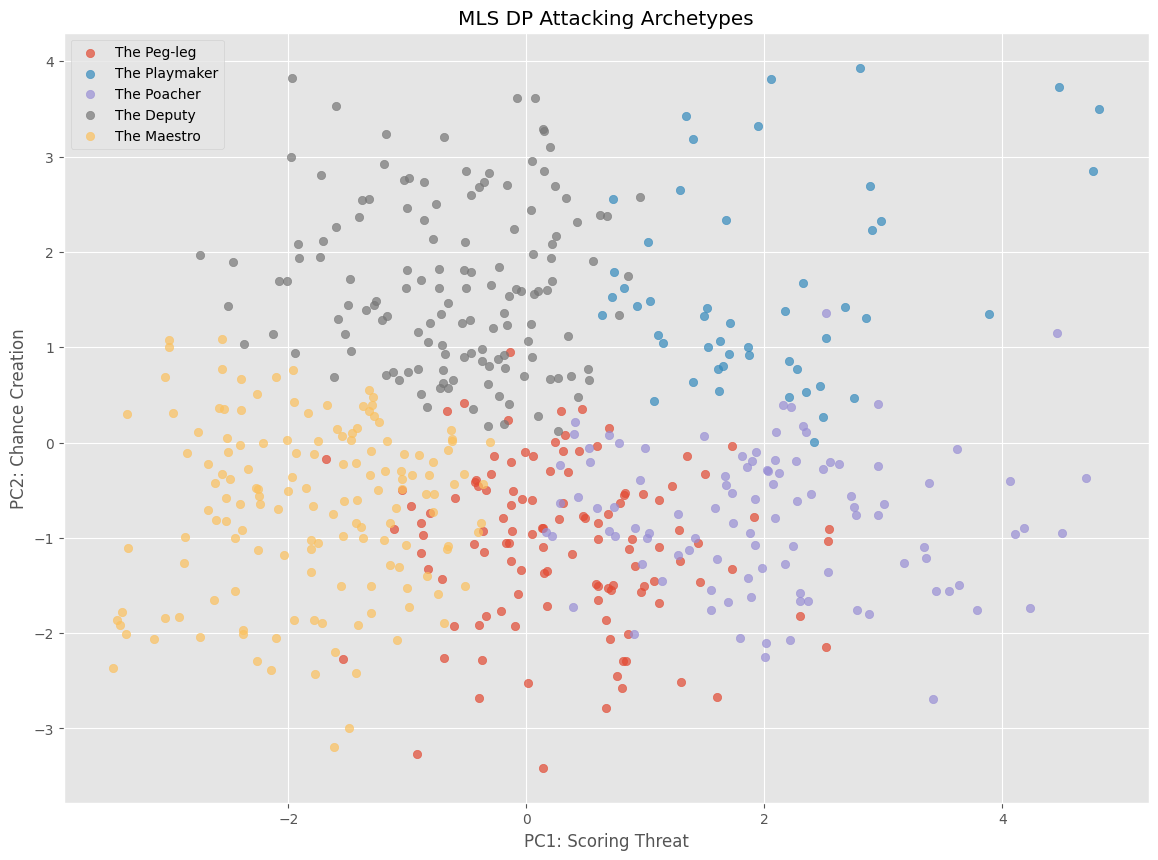

In [43]:
# PC1 and PC2 plot for all clusters

plt.figure(figsize=(14, 10))

for archetype in df["archetype"].unique():

    subset = df[
        df["archetype"] == archetype
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=archetype
    )

plt.xlabel("PC1: Scoring Threat")
plt.ylabel("PC2: Chance Creation")

plt.title("MLS DP Attacking Archetypes")

plt.legend()

plt.grid(True)

plt.show()

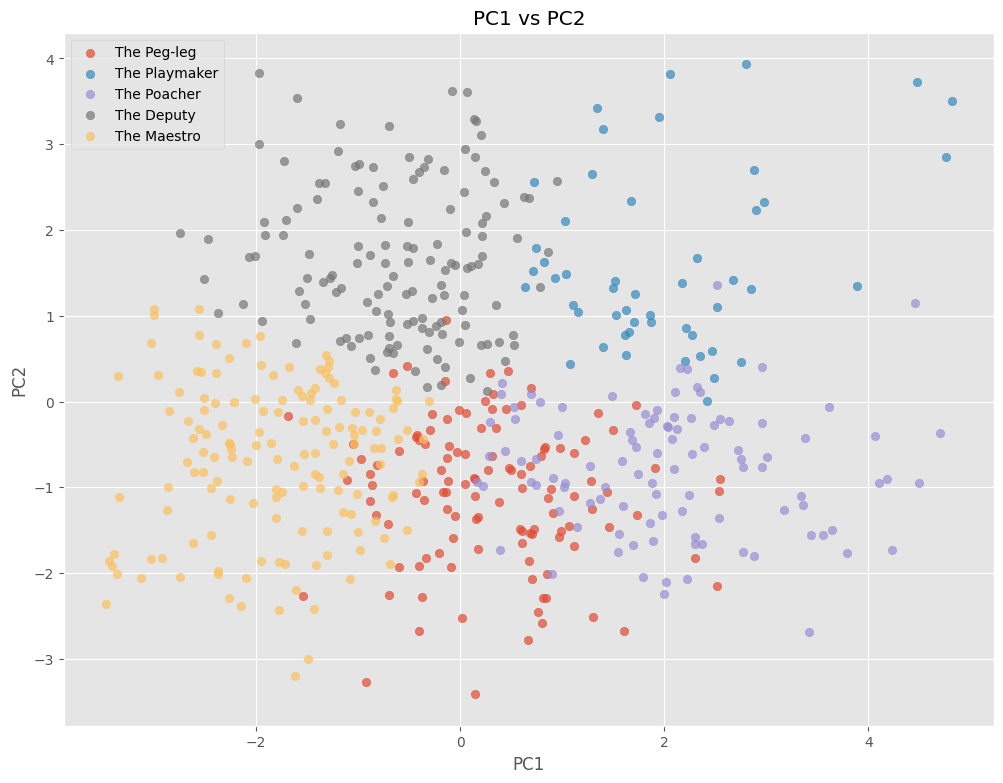

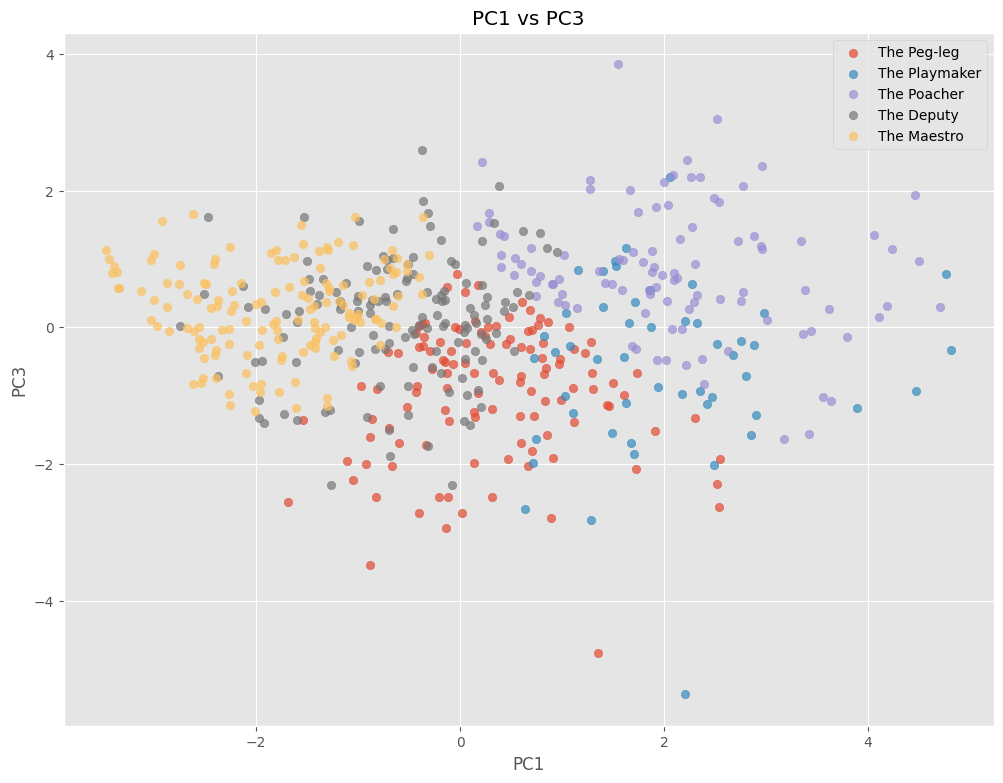

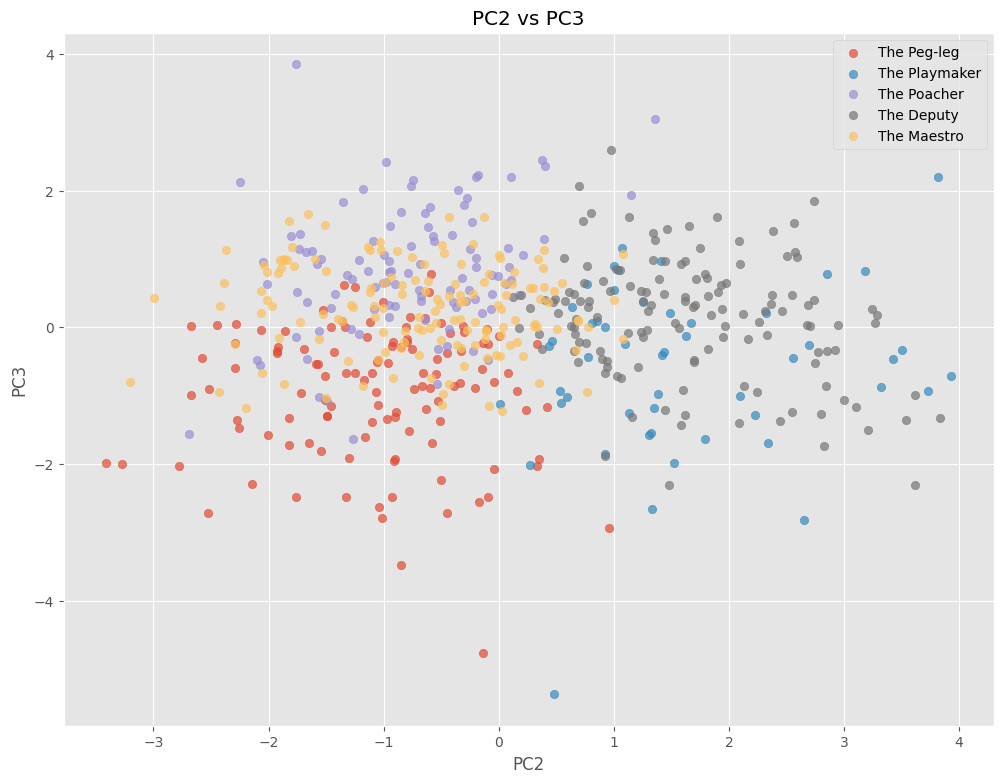

In [44]:
# Permutations of the PC space plots

import itertools
import matplotlib.pyplot as plt

pc_pairs = list(
    itertools.combinations(
        ["PC1", "PC2", "PC3"],
        2
    )
)

for x_pc, y_pc in pc_pairs:

    plt.figure(figsize=(12, 9))

    for archetype in df["archetype"].unique():

        subset = df[
            df["archetype"] == archetype
        ]

        plt.scatter(
            subset[x_pc],
            subset[y_pc],
            alpha=0.7,
            label=archetype
        )

    plt.xlabel(x_pc)
    plt.ylabel(y_pc)

    plt.title(
        f"{x_pc} vs {y_pc}"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

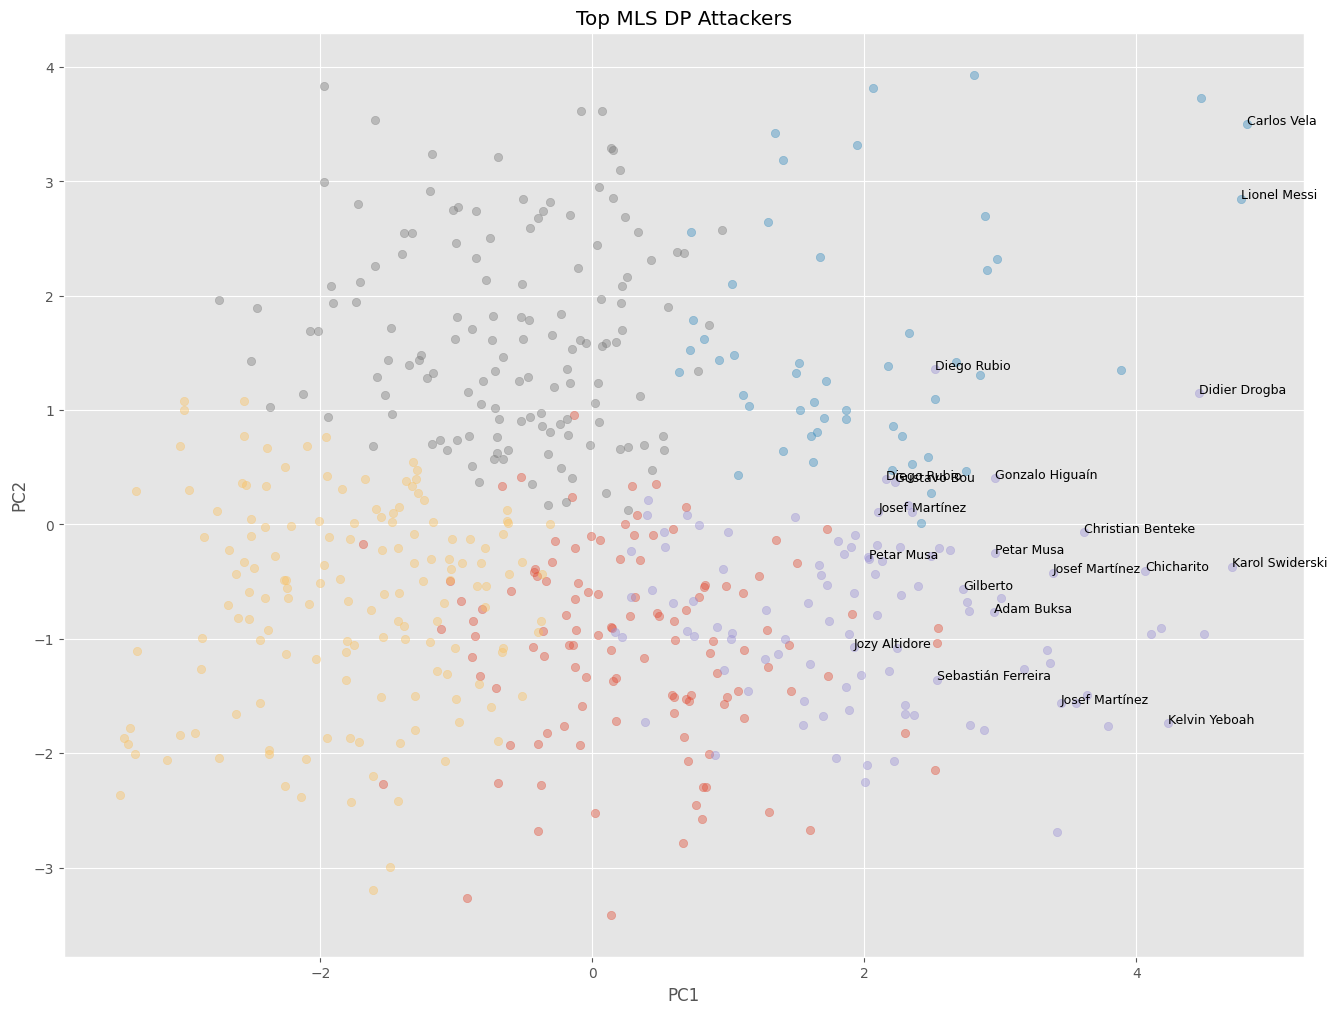

In [45]:
# Top players labeled on a plot

top_players = df.nlargest(
    20,
    "points_added_per96"
)

plt.figure(figsize=(16, 12))

for archetype in df["archetype"].unique():

    subset = df[
        df["archetype"] == archetype
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.4
    )

for _, row in top_players.iterrows():

    plt.text(
        row["PC1"],
        row["PC2"],
        row["player_name"],
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Top MLS DP Attackers")

plt.grid(True)

plt.show()